In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import calendar
import datetime

In [3]:
df = pd.read_csv("tmdb_top_rated_movies.xls")

In [5]:
df.head()

,id,original_language,overview,release_date,title,popularity,vote_average,vote_count
0,278,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,The Shawshank Redemption,35.0440,8.708,28176
1,238,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,The Godfather,36.3040,8.687,21363
2,240,en,In the continuing saga of the Corleone crime f...,1974-12-20,The Godfather Part II,17.2441,8.570,12910
3,424,en,The true story of how businessman Oskar Schind...,1993-12-15,Schindler's List,37.5490,8.564,16380
4,389,en,The defense and the prosecution have rested an...,1957-04-10,12 Angry Men,17.0033,8.548,9091


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   original_language  10000 non-null  object 
 2   overview           10000 non-null  object 
 3   release_date       9998 non-null   object 
 4   title              10000 non-null  object 
 5   popularity         10000 non-null  float64
 6   vote_average       10000 non-null  float64
 7   vote_count         10000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 625.1+ KB


In [7]:
df['release_date']= pd.to_datetime(df['release_date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 10000 non-null  int64         
 1   original_language  10000 non-null  object        
 2   overview           10000 non-null  object        
 3   release_date       9998 non-null   datetime64[ns]
 4   title              10000 non-null  object        
 5   popularity         10000 non-null  float64       
 6   vote_average       10000 non-null  float64       
 7   vote_count         10000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 625.1+ KB


In [9]:
df.describe()

,id,release_date,popularity,vote_average,vote_count
count,1.000000e+04,9998,10000.000000,10000.000000,10000.000000
mean,2.070686e+05,2005-02-07 18:13:02.076415232,5.864129,6.652452,2015.950900
min,2.000000e+00,1902-06-15 00:00:00,0.007500,4.583000,300.000000
25%,1.028450e+04,1998-02-11 12:00:00,2.353925,6.126000,467.000000
50%,3.921850e+04,2010-02-14 00:00:00,4.009800,6.669000,845.000000
75%,3.772632e+05,2017-05-25 00:00:00,6.624200,7.200000,1999.250000
max,1.356039e+06,2025-04-09 00:00:00,517.542500,8.708000,37385.000000
std,2.732769e+05,NaN,10.399510,0.741678,3215.961515


In [10]:
df[df["overview"].isnull()]

,id,original_language,overview,release_date,title,popularity,vote_average,vote_count


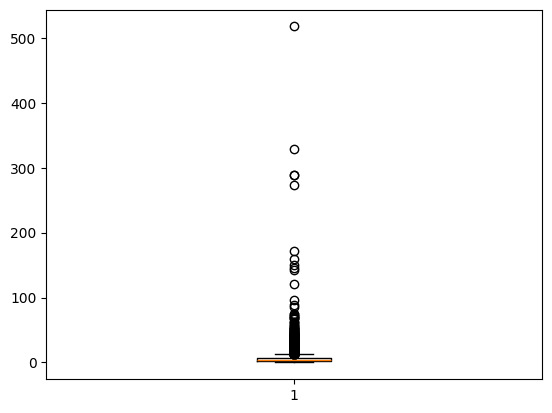

In [11]:
plt.boxplot(df['popularity'], vert=True)
plt.show()

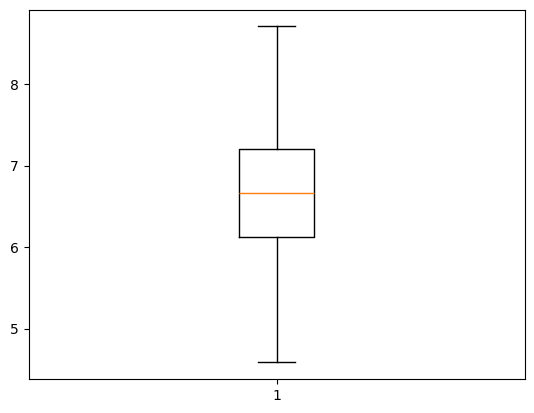

In [12]:
plt.boxplot(df['vote_average'])
plt.show()

In [13]:
df.head(1)

,id,original_language,overview,release_date,title,popularity,vote_average,vote_count
0,278,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,The Shawshank Redemption,35.044,8.708,28176


In [14]:
df.corr(numeric_only=True)
# as we can see there is weak relationship between numerical attributes

,id,popularity,vote_average,vote_count
id,1.000000,0.168151,0.012630,-0.091975
popularity,0.168151,1.000000,0.135400,0.340507
vote_average,0.012630,0.135400,1.000000,0.284395
vote_count,-0.091975,0.340507,0.284395,1.000000


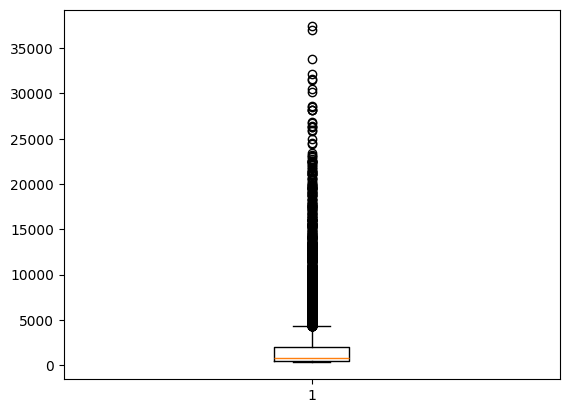

In [15]:
plt.boxplot(df['vote_count'])
plt.show()

In [16]:
# as we analys our numerical columns we find that there is too many outliers in vote_count
# and popularity columns and we also saw that there is no good relation between numerical 
# attributes so we are dropping the entire popularity and vote_count column and let 
# we see vote_average column what can we do with that.

In [19]:
df1 = df.drop(columns=['popularity', 'vote_count'])

In [20]:
df1.head(1)

,id,original_language,overview,release_date,title,vote_average
0,278,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,The Shawshank Redemption,8.708


In [21]:
# now lets create a column where we will store the categorical data and then we process them 
# to create embedding of that and then applying tokenization. 

In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [23]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 10000 non-null  int64         
 1   original_language  10000 non-null  object        
 2   overview           10000 non-null  object        
 3   release_date       9998 non-null   datetime64[ns]
 4   title              10000 non-null  object        
 5   vote_average       10000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 468.9+ KB


In [24]:
df1[df1['overview'].isnull()]

,id,original_language,overview,release_date,title,vote_average


In [25]:
df1[df1['release_date'].isnull()]

,id,original_language,overview,release_date,title,vote_average
5424,1198870,en,A girl is at school. Suddenly it's as if she c...,NaT,Return,6.577
5515,733668,hy,Eyüp decides to cross mount Ararat looking for...,NaT,Return,6.557


In [26]:
df1.query("title == 'Return'")

,id,original_language,overview,release_date,title,vote_average
3138,357953,en,Return is a methodical construction of the app...,1975-09-04,Return,7.046
3169,357953,en,Return is a methodical construction of the app...,1975-09-04,Return,7.043
5043,464446,en,A young man returns home for the weekend to di...,2015-07-04,Return,6.655
5058,839321,pl,Polish animator Anna Błaszczyk’s humorous shor...,2008-01-01,Return,6.653
5424,1198870,en,A girl is at school. Suddenly it's as if she c...,NaT,Return,6.577
5442,320367,en,A tale of terror. Cathy Reed has been institut...,2015-01-01,Return,6.573
5515,733668,hy,Eyüp decides to cross mount Ararat looking for...,NaT,Return,6.557
5535,348877,en,Static images of an old country house are comb...,1972-07-15,Return,6.554
5883,670355,en,"Owen, a young man is dissatisfied with his lif...",2020-01-28,Return,6.481
6076,379862,en,A young couple purchase their new home to star...,2015-11-28,Return,6.444


In [27]:
df1['data'] = df1['overview'] + " " + df1['title'] + " " + df1['original_language']

In [28]:
df1['data'][0]

'Imprisoned in the 1940s for the double murder of his wife and her lover, upstanding banker Andy Dufresne begins a new life at the Shawshank prison, where he puts his accounting skills to work for an amoral warden. During his long stretch in prison, Dufresne comes to be admired by the other inmates -- including an older prisoner named Red -- for his integrity and unquenchable sense of hope. The Shawshank Redemption en'

In [29]:
# df1.isnull().sum() 
df1.shape

(10000, 7)

In [30]:
df1.dropna(subset=['overview'], inplace=True)

In [31]:
df1.isnull().sum()

id                   0
original_language    0
overview             0
release_date         2
title                0
vote_average         0
data                 0
dtype: int64

In [32]:
# here we are not using date function for recommendation we and there is only two columns we can randomly give the date or ffill or bfill

In [33]:
df1[df1.release_date.isnull()]

,id,original_language,overview,release_date,title,vote_average,data
5424,1198870,en,A girl is at school. Suddenly it's as if she c...,NaT,Return,6.577,A girl is at school. Suddenly it's as if she c...
5515,733668,hy,Eyüp decides to cross mount Ararat looking for...,NaT,Return,6.557,Eyüp decides to cross mount Ararat looking for...


In [34]:
df1.duplicated().sum()

np.int64(214)

In [35]:
# df1[df1.duplicated()]
# there is existance of duplicated data 

In [36]:
df1.drop_duplicates(keep='first', inplace=True)

In [37]:
df1.shape

(9786, 7)

In [38]:
df1['release_date'].ffill(inplace=True)

/var/folders/p3/g25fc4fn5_94qr376nhv0tk80000gn/T/ipykernel_8077/1887424260.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['release_date'].ffill(inplace=True)


In [39]:
df1.iloc[5480]

id                                                               11899
original_language                                                   en
overview             When the Muppets graduate from Danhurst Colleg...
release_date                                       1984-06-27 00:00:00
title                                       The Muppets Take Manhattan
vote_average                                                     6.547
data                 When the Muppets graduate from Danhurst Colleg...
Name: 5570, dtype: object

In [40]:
df1.describe()

,id,release_date,vote_average
count,9.786000e+03,9786,9786.000000
mean,2.066534e+05,2005-01-20 10:40:32.372777472,6.658120
min,2.000000e+00,1902-06-15 00:00:00,4.583000
25%,1.025125e+04,1998-02-05 06:00:00,6.132250
50%,3.921850e+04,2010-02-10 00:00:00,6.675000
75%,3.768138e+05,2017-05-18 18:00:00,7.200000
max,1.356039e+06,2025-04-09 00:00:00,8.708000
std,2.727356e+05,NaN,0.742753


In [41]:
# now we cleaned our data and we have to process further

In [42]:
df1.tail(1)

,id,original_language,overview,release_date,title,vote_average,data
9999,10285,en,Jason Voorhees is tracked down and blown to bi...,1993-08-13,Jason Goes to Hell: The Final Friday,4.6,Jason Voorhees is tracked down and blown to bi...


In [43]:
df1.reset_index(inplace=True, drop='index')

In [44]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [45]:
# we have to tokenize our data 
bow = CountVectorizer(stop_words='english', token_pattern='[a-zA-Z]{2,}', max_features=70000, ngram_range=(1,1))

vectorized = bow.fit_transform(df1['data'])
vectorized

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 246517 stored elements and shape (9786, 27829)>

In [46]:
user = 'The Crow: City of Angels'

ind = pd.Series(df1.index, index=df1['title'])

movie = ind[user]

similarity = cosine_similarity(vectorized[movie], vectorized).flatten()
top = similarity.argsort()[::-1][1:6]


In [47]:
df1.iloc[top]

,id,original_language,overview,release_date,title,vote_average,data
7664,70821,en,A woman tries to help her teenage daughter whe...,2011-11-10,Cyberbully,6.054,A woman tries to help her teenage daughter whe...
1213,9495,en,Exactly one year after young rock guitarist Er...,1994-05-11,The Crow,7.527,Exactly one year after young rock guitarist Er...
1722,17136,en,A seductive woman gets an innocent professor m...,1944-10-25,The Woman in the Window,7.382,A seductive woman gets an innocent professor m...
8893,302150,en,An assassin forges an unlikely partnership wit...,2017-06-08,The Hunter's Prayer,5.644,An assassin forges an unlikely partnership wit...
8208,462148,fr,Gabriel can't resist a beautiful woman. But hi...,2018-04-18,Love Addict,5.909,Gabriel can't resist a beautiful woman. But hi...


In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [49]:

tfidf = TfidfVectorizer(stop_words='english', token_pattern='[a-zA-Z]{2,}')

tf_vec = tfidf.fit_transform(df1['data'])

In [50]:
tf_sim = cosine_similarity(tf_vec[movie], tf_vec).flatten()
tf_top = tf_sim.argsort()[::-1][1:6]
df1['title'].iloc[tf_top]

1213               The Crow
9076    The Crow: Salvation
8417               The Crow
2806       Dead Man's Shoes
8426       Charlie's Angels
Name: title, dtype: object

In [51]:
df1.iloc[9268]

id                                                               92182
original_language                                                   en
overview             Sarah returns with her father and uncle to fix...
release_date                                       2011-01-21 00:00:00
title                                                     Silent House
vote_average                                                     5.426
data                 Sarah returns with her father and uncle to fix...
Name: 9268, dtype: object

In [52]:
df1.iloc[1273]

id                                                                 229
original_language                                                   en
overview             Dr. Frankenstein and his monster both turn out...
release_date                                       1935-04-20 00:00:00
title                                            Bride of Frankenstein
vote_average                                                       7.5
data                 Dr. Frankenstein and his monster both turn out...
Name: 1273, dtype: object